# 02 - Treino DNN (NumPy)

Deep Neural Network treinada do zero usando NumPy.

- **Dataset**: `data/processed/dataset_combined.csv`
- **Validações**: `dataset-exemplos.csv` e `subm1_labels_revealed.csv`
- **Vectorizers**: forensic, stylometric, stylometric_only
- **Método**: Random search com 20 iterações

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc
)

from src.data_processing import clean_text
from src.vectorizer import create_vectorizer
from src.models_numpy.dnn.neuralnet import NeuralNetwork
from src.models_numpy.dnn.layers import DenseLayer, DropoutLayer, BatchNormalizationLayer
from src.models_numpy.dnn.activation import ReLUActivation, SoftmaxActivation
from src.models_numpy.dnn.losses import CategoricalCrossEntropy
from src.models_numpy.dnn.metrics import accuracy
from src.models_numpy.dnn.dataset import Dataset
from src.models_numpy.dnn.optimizer import AdamOptimizer, SGDOptimizer

In [3]:
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

## 1. Carregamento de Dados

In [4]:
# Constantes
ROOT = os.path.abspath('..')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
VAL1_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
VAL2_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')

print(f'Classes: {LABEL_MAP}')

Classes: {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'OpenAI': 4}


In [5]:
def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    df['text_clean'] = df['Text'].apply(clean_text)
    return df

def one_hot(labels, n_classes=NUM_CLASSES):
    oh = np.zeros((len(labels), n_classes))
    for i, l in enumerate(labels):
        oh[i, l] = 1
    return oh

In [6]:
df_train = load_data(TRAIN_PATH)
df_val1 = load_data(VAL1_PATH)
df_val2 = load_data(VAL2_PATH)

print(f'Train: {len(df_train)} amostras')
print(f'  Labels: {df_train["Label"].value_counts().to_dict()}')
print(f'Val1 (exemplos): {len(df_val1)} amostras')
print(f'  Labels: {df_val1["Label"].value_counts().to_dict()}')
print(f'Val2 (subm1): {len(df_val2)} amostras')
print(f'  Labels: {df_val2["Label"].value_counts().to_dict()}')

Train: 2195 amostras
  Labels: {'Anthropic': 500, 'OpenAI': 481, 'Google': 480, 'Meta': 480, 'Human': 254}
Val1 (exemplos): 125 amostras
  Labels: {'Human': 52, 'Anthropic': 23, 'Meta': 17, 'OpenAI': 17, 'Google': 16}
Val2 (subm1): 100 amostras
  Labels: {'Human': 34, 'Meta': 18, 'Anthropic': 17, 'Google': 17, 'OpenAI': 14}


## 2. Param Grid para Random Search

In [7]:
param_grid = {
    'vectorizer_type': ['forensic', 'stylometric', 'stylometric_only'],
    'max_words': [500, 1000],
    'hidden_layers': [
        [128, 64],
        [256, 128],
        [128, 64, 32],
        [64, 32],
    ],
    'dropout': [0.3, 0.4, 0.5],
    'lr': [0.001, 0.005, 0.01],
    'batch_size': [32, 64, 128],
    'use_batchnorm': [True, False],
}

print('Opções por parâmetro:')
for k, v in param_grid.items():
    print(f'  {k}: {len(v)} opções')

Opções por parâmetro:
  vectorizer_type: 3 opções
  max_words: 2 opções
  hidden_layers: 4 opções
  dropout: 3 opções
  lr: 3 opções
  batch_size: 3 opções
  use_batchnorm: 2 opções


In [8]:
def sample_params(grid, rng):
    return {k: rng.choice(v) for k, v in grid.items()}

## 3. Função de Treino

In [ ]:
def train_dnn(params, X_train, y_train_oh, X_val, y_val_oh, num_classes):
    opt = AdamOptimizer(learning_rate=params['lr'])
    
    model = NeuralNetwork(
        epochs=100,
        batch_size=params['batch_size'],
        optimizer=opt,
        loss=CategoricalCrossEntropy,
        metric=accuracy,
        early_stopping=True,
        patience=15,
        verbose=False,
    )
    
    input_dim = X_train.shape[1]
    prev_dim = input_dim
    
    for h in params['hidden_layers']:
        model.add(DenseLayer(h, prev_dim))
        if params['use_batchnorm']:
            model.add(BatchNormalizationLayer())
        model.add(ReLUActivation())
        if params['dropout'] > 0:
            model.add(DropoutLayer(params['dropout']))
        prev_dim = h
    
    model.add(DenseLayer(num_classes, prev_dim))
    model.add(SoftmaxActivation())
    
    ds_train = Dataset(X_train, y_train_oh)
    ds_val = Dataset(X_val, y_val_oh)
    
    t0 = time.time()
    history = model.fit(ds_train, ds_val)
    train_time = time.time() - t0
    
    val_acc = max(history.get('val_acc', [0]))
    train_acc = max(history.get('train_acc', [0]))
    
    return model, val_acc, train_acc, history, train_time


def evaluate_external(model, vectorizer, df_ext, needs_raw):
    texts_clean = list(df_ext['text_clean'])
    labels = df_ext['label_id'].values
    
    if needs_raw:
        X = vectorizer.transform(texts_clean, list(df_ext['Text']))
    else:
        X = vectorizer.transform(texts_clean)
    
    y_oh = one_hot(labels)
    ds = Dataset(X, y_oh)
    preds = model.predict(ds)
    return accuracy(y_oh, preds)

## 4. Random Search (20 iterações)

In [10]:
SEED = 42
N_ITERATIONS = 20
random.seed(SEED)
np.random.seed(SEED)

results = []
best_val1_acc = -1
best_model = None
best_vectorizer = None
best_params = None

print(f'=== Random Search: DNN (NumPy) — {N_ITERATIONS} iterações ===')
print()

for i in range(N_ITERATIONS):
    params = sample_params(param_grid, random)
    vtype = params['vectorizer_type']
    
    print(f'[{i+1}/{N_ITERATIONS}] {vtype} | hidden={params["hidden_layers"]} '
          f'dropout={params["dropout"]} lr={params["lr"]} bs={params["batch_size"]}')
    
    try:
        needs_raw = vtype in ['forensic', 'stylometric', 'stylometric_only']
        vec = create_vectorizer(vtype, max_words=params['max_words'])
        
        t0 = time.time()
        if needs_raw:
            X_all = vec.fit_transform(list(df_train['text_clean']), list(df_train['Text']))
        else:
            X_all = vec.fit_transform(list(df_train['text_clean']))
        vec_time = time.time() - t0
        
        y_all = df_train['label_id'].values
        y_all_oh = one_hot(y_all)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all_oh, test_size=0.2, random_state=42, stratify=y_all
        )
        
        model, val_acc, train_acc, history, train_time = train_dnn(
            params, X_tr, y_tr, X_te, y_te, NUM_CLASSES
        )
        
        val1_acc = evaluate_external(model, vec, df_val1, needs_raw)
        val2_acc = evaluate_external(model, vec, df_val2, needs_raw)
        
        print(f'  -> internal={val_acc:.4f} | val1={val1_acc:.4f} | val2={val2_acc:.4f} '
              f'({train_time:.1f}s)')
        
        results.append({
            'iteration': i + 1,
            'vectorizer': vtype,
            'hidden_layers': str(params['hidden_layers']),
            'dropout': params['dropout'],
            'lr': params['lr'],
            'batch_size': params['batch_size'],
            'use_batchnorm': params['use_batchnorm'],
            'max_words': params['max_words'],
            'internal_val': val_acc,
            'train_acc': train_acc,
            'val1_acc': val1_acc,
            'val2_acc': val2_acc,
            'train_time': train_time,
            'vec_time': vec_time,
        })
        
        if val1_acc > best_val1_acc:
            best_val1_acc = val1_acc
            best_model = model
            best_vectorizer = vec
            best_params = params
            print(f'  *** NOVO MELHOR ***')
    
    except Exception as e:
        print(f'  -> ERRO: {e}')
        results.append({
            'iteration': i + 1,
            'vectorizer': vtype,
            'error': str(e),
        })

print(f'\n=== Concluído ===')

=== Random Search: DNN (NumPy) — 20 iterações ===

[1/20] stylometric_only | hidden=[128, 64] dropout=0.5 lr=0.005 bs=32
  -> internal=0.9385 | val1=0.3840 | val2=0.5300 (1.4s)
  *** NOVO MELHOR ***
[2/20] forensic | hidden=[128, 64] dropout=0.5 lr=0.005 bs=32
  -> internal=0.9385 | val1=0.4000 | val2=0.4900 (4.9s)
  *** NOVO MELHOR ***
[3/20] forensic | hidden=[256, 128] dropout=0.5 lr=0.01 bs=32
  -> internal=0.9248 | val1=0.4000 | val2=0.4600 (6.1s)
[4/20] stylometric_only | hidden=[256, 128] dropout=0.4 lr=0.01 bs=64
  -> internal=0.9294 | val1=0.3840 | val2=0.5200 (2.3s)
[5/20] forensic | hidden=[128, 64, 32] dropout=0.4 lr=0.001 bs=32
  -> internal=0.9431 | val1=0.4640 | val2=0.5200 (5.1s)
  *** NOVO MELHOR ***
[6/20] forensic | hidden=[64, 32] dropout=0.3 lr=0.005 bs=64
  -> internal=0.9385 | val1=0.5040 | val2=0.5500 (0.9s)
  *** NOVO MELHOR ***
[7/20] forensic | hidden=[128, 64] dropout=0.4 lr=0.001 bs=128
  -> internal=0.9317 | val1=0.4720 | val2=0.5100 (2.8s)
[8/20] stylomet

## 5. Resultados

In [11]:
results_df = pd.DataFrame(results)
results_df = results_df[results_df['error'].isna() if 'error' in results_df.columns else results_df.notna().all(axis=1)]

if 'val1_acc' in results_df.columns and len(results_df) > 0:
    print('=== Top 5 Modelos (por val1_acc) ===')
    print()
    top5 = results_df.nlargest(5, 'val1_acc')[
        ['iteration', 'vectorizer', 'hidden_layers', 'dropout', 'lr',
         'internal_val', 'val1_acc', 'val2_acc']
    ]
    print(top5.to_string(index=False))
    
    print('\n=== Top 5 Modelos (por val2_acc) ===')
    print()
    top5_val2 = results_df.nlargest(5, 'val2_acc')[
        ['iteration', 'vectorizer', 'hidden_layers', 'dropout', 'lr',
         'internal_val', 'val1_acc', 'val2_acc']
    ]
    print(top5_val2.to_string(index=False))

=== Top 5 Modelos (por val1_acc) ===

 iteration vectorizer hidden_layers  dropout    lr  internal_val  val1_acc  val2_acc
         6   forensic      [64, 32]      0.3 0.005      0.938497     0.504      0.55
        18   forensic    [256, 128]      0.5 0.005      0.945330     0.480      0.54
         7   forensic     [128, 64]      0.4 0.001      0.931663     0.472      0.51
         5   forensic [128, 64, 32]      0.4 0.001      0.943052     0.464      0.52
         2   forensic     [128, 64]      0.5 0.005      0.938497     0.400      0.49

=== Top 5 Modelos (por val2_acc) ===

 iteration       vectorizer hidden_layers  dropout    lr  internal_val  val1_acc  val2_acc
         6         forensic      [64, 32]      0.3 0.005      0.938497     0.504      0.55
        12      stylometric [128, 64, 32]      0.5 0.010      0.936219     0.392      0.55
        15 stylometric_only      [64, 32]      0.5 0.005      0.933941     0.384      0.54
        18         forensic    [256, 128]      0.

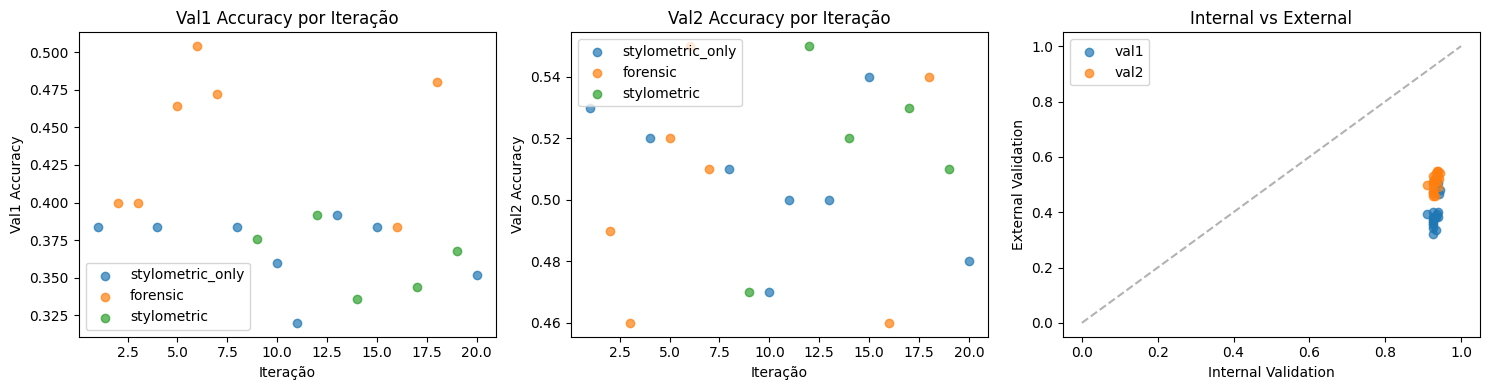

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Val1 accuracy por vectorizer
for vtype in results_df['vectorizer'].unique():
    mask = results_df['vectorizer'] == vtype
    axes[0].scatter(results_df[mask]['iteration'], results_df[mask]['val1_acc'], 
                   label=vtype, alpha=0.7)
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('Val1 Accuracy')
axes[0].set_title('Val1 Accuracy por Iteração')
axes[0].legend()

# Val2 accuracy por vectorizer
for vtype in results_df['vectorizer'].unique():
    mask = results_df['vectorizer'] == vtype
    axes[1].scatter(results_df[mask]['iteration'], results_df[mask]['val2_acc'], 
                   label=vtype, alpha=0.7)
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('Val2 Accuracy')
axes[1].set_title('Val2 Accuracy por Iteração')
axes[1].legend()

# Internal vs External
axes[2].scatter(results_df['internal_val'], results_df['val1_acc'], 
               label='val1', alpha=0.7)
axes[2].scatter(results_df['internal_val'], results_df['val2_acc'], 
               label='val2', alpha=0.7)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('Internal Validation')
axes[2].set_ylabel('External Validation')
axes[2].set_title('Internal vs External')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Avaliação Detalhada do Melhor Modelo

In [13]:
print('=== Melhor Modelo ===')
print(f"Vectorizer: {best_params['vectorizer_type']}")
print(f"Hidden layers: {best_params['hidden_layers']}")
print(f"Dropout: {best_params['dropout']}")
print(f"Learning rate: {best_params['lr']}")
print(f"Batch size: {best_params['batch_size']}")
print(f"BatchNorm: {best_params['use_batchnorm']}")

=== Melhor Modelo ===
Vectorizer: forensic
Hidden layers: [64, 32]
Dropout: 0.3
Learning rate: 0.005
Batch size: 64
BatchNorm: False


In [ ]:
def full_evaluation(model, vec, df_ext, name, needs_raw):
    texts_clean = list(df_ext['text_clean'])
    labels = df_ext['label_id'].values
    
    if needs_raw:
        X = vec.transform(texts_clean, list(df_ext['Text']))
    else:
        X = vec.transform(texts_clean)
    
    y_oh = one_hot(labels)
    ds = Dataset(X, y_oh)
    preds_probs = model.predict(ds)
    preds = np.argmax(preds_probs, axis=1)
    
    acc = accuracy_score(labels, preds)
    
    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print()
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ylabel='Real',
        xlabel='Previsto',
        title=f'Matriz de Confusão — {name}',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    
    plt.tight_layout()
    plt.show()
    
    return preds_probs, labels


=== Val1 (exemplos) ===
Accuracy: 0.5040

              precision    recall  f1-score   support

   Anthropic       0.38      0.22      0.28        23
      Google       0.23      0.38      0.29        16
       Human       0.73      0.77      0.75        52
        Meta       0.50      0.24      0.32        17
      OpenAI       0.35      0.47      0.40        17

    accuracy                           0.50       125
   macro avg       0.44      0.41      0.41       125
weighted avg       0.52      0.50      0.50       125



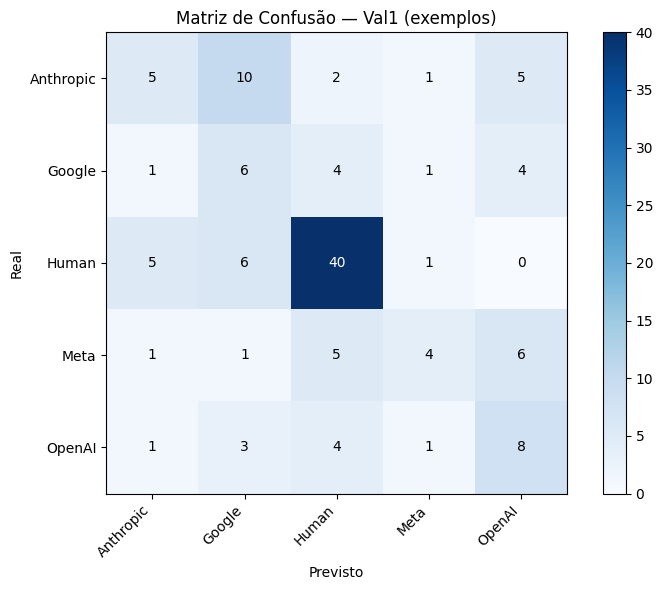


=== Val2 (subm1) ===
Accuracy: 0.5500

              precision    recall  f1-score   support

   Anthropic       0.57      0.24      0.33        17
      Google       0.60      0.71      0.65        17
       Human       0.68      0.82      0.75        34
        Meta       0.70      0.39      0.50        18
      OpenAI       0.18      0.29      0.22        14

    accuracy                           0.55       100
   macro avg       0.55      0.49      0.49       100
weighted avg       0.58      0.55      0.54       100



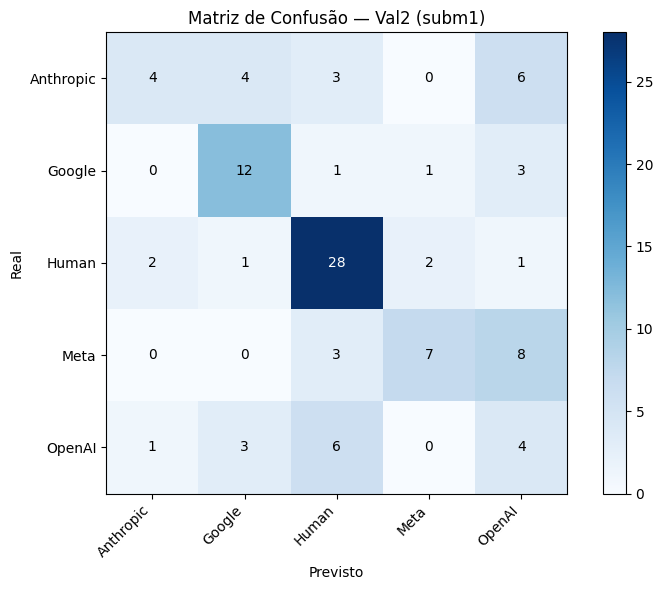

In [15]:
needs_raw = best_params['vectorizer_type'] in ['forensic', 'stylometric', 'stylometric_only']

probs_val1, labels_val1 = full_evaluation(best_model, best_vectorizer, df_val1, 'Val1 (exemplos)', needs_raw)
probs_val2, labels_val2 = full_evaluation(best_model, best_vectorizer, df_val2, 'Val2 (subm1)', needs_raw)

## 7. Curva ROC (Macro Average)

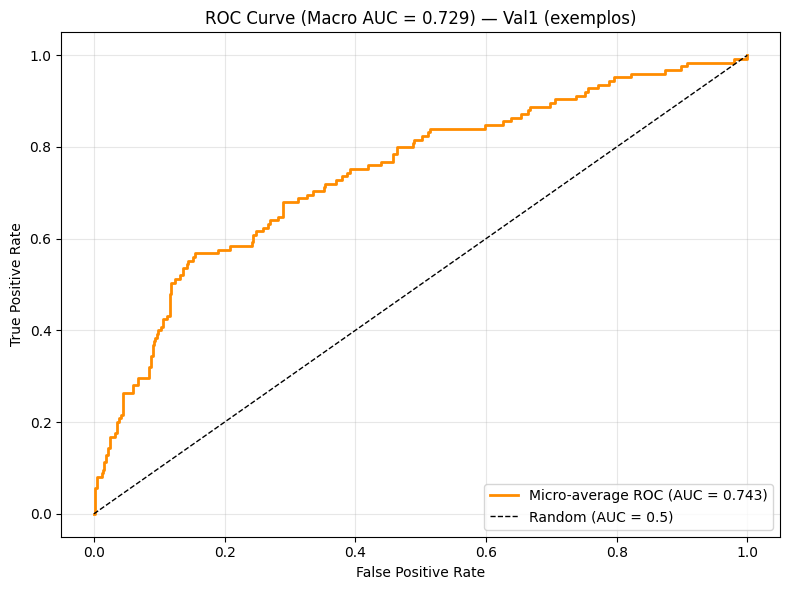

Val1 (exemplos): Micro AUC = 0.7432, Macro AUC = 0.7293


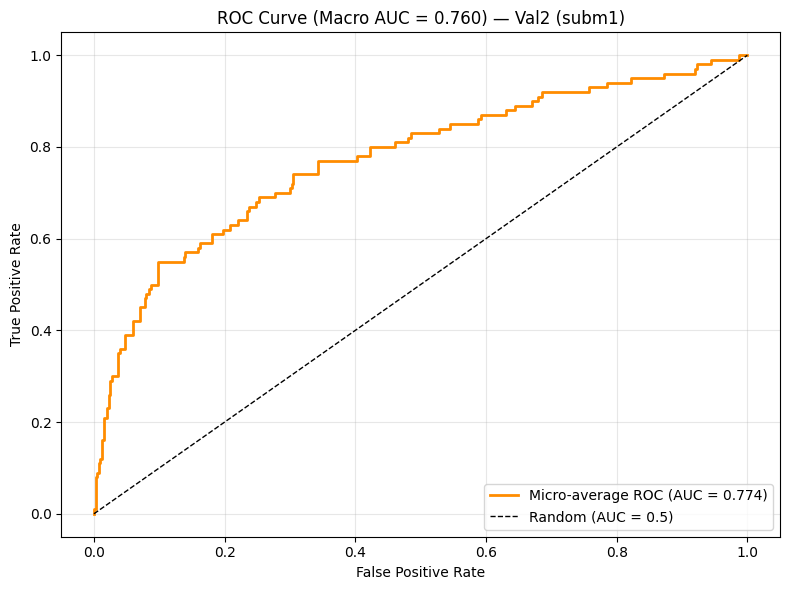

Val2 (subm1): Micro AUC = 0.7740, Macro AUC = 0.7600


In [ ]:
from sklearn.preprocessing import label_binarize

def plot_roc_macro(probs, labels, name):
    """Plota curva ROC macro average."""
    labels_bin = label_binarize(labels, classes=range(NUM_CLASSES))
    
    fpr, tpr, _ = roc_curve(labels_bin.ravel(), probs.ravel())
    roc_auc = auc(fpr, tpr)
    
    aucs = []
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], probs[:, i])
        aucs.append(auc(fpr_i, tpr_i))
    macro_auc = np.mean(aucs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Micro-average ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Macro AUC = {macro_auc:.3f}) — {name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f'{name}: Micro AUC = {roc_auc:.4f}, Macro AUC = {macro_auc:.4f}')
    return macro_auc

macro_auc_val1 = plot_roc_macro(probs_val1, labels_val1, 'Val1 (exemplos)')
macro_auc_val2 = plot_roc_macro(probs_val2, labels_val2, 'Val2 (subm1)')

## 8. Conclusões

In [ ]:
print('=' * 60)
print('CONCLUSÕES — DNN (NumPy)')
print('=' * 60)
print()

print('Média por vectorizer:')
for vtype in results_df['vectorizer'].unique():
    mask = results_df['vectorizer'] == vtype
    mean_v1 = results_df[mask]['val1_acc'].mean()
    mean_v2 = results_df[mask]['val2_acc'].mean()
    print(f'  {vtype:20s}: val1={mean_v1:.4f} | val2={mean_v2:.4f}')

print()
print('Melhor configuração:')
print(f"  Vectorizer: {best_params['vectorizer_type']}")
print(f"  Hidden layers: {best_params['hidden_layers']}")
print(f"  Dropout: {best_params['dropout']}")
print(f"  LR: {best_params['lr']}")
print(f"  Batch size: {best_params['batch_size']}")
print(f"  BatchNorm: {best_params['use_batchnorm']}")
print()
print(f'Val1 Accuracy: {best_val1_acc:.4f}')
print(f'Val1 AUC (macro): {macro_auc_val1:.4f}')
print(f'Val2 Accuracy: {results_df.loc[results_df["val1_acc"].idxmax(), "val2_acc"]:.4f}')
print(f'Val2 AUC (macro): {macro_auc_val2:.4f}')

CONCLUSÕES — DNN (NumPy)

Média por vectorizer:
  stylometric_only    : val1=0.3700 | val2=0.5063
  forensic            : val1=0.4434 | val2=0.5043
  stylometric         : val1=0.3632 | val2=0.5160

Melhor configuração:
  Vectorizer: forensic
  Hidden layers: [64, 32]
  Dropout: 0.3
  LR: 0.005
  Batch size: 64
  BatchNorm: False

Val1 Accuracy: 0.5040
Val1 AUC (macro): 0.7293
Val2 Accuracy: 0.5500
Val2 AUC (macro): 0.7600
